# 122 · Chess Siamese — Open-Set ELO At Scale (modelo 120)

Notebook de evaluación **solo open-set / ELO**.

Carga el modelo entrenado en `120`, construye su memoria de referencia con las partidas
del evento `compressed_120` y lanza una batería masiva sobre jugadores **nunca vistos**.


## Objetivo y protocolo

- Evaluar únicamente la **capacidad de asimilar/predicir ELO** en jugadores no vistos.
- Muestrear **2000 jugadores arbitrarios** con ELO muy variado desde la base grande de `pgn_output`.
- Tomar **20 partidas arbitrarias** por jugador con `reservoir sampling` en streaming.
- Medir la predicción de ELO a nivel **partida** y a nivel **jugador**.
- Guardar resultados **incrementalmente** para poder reanudar la ejecución si se corta.

Métodos de predicción incluidos:

1. `exemplar_top1`: ELO de la partida conocida más cercana.
2. `exemplar_knn`: promedio ponderado por distancia de las `k` partidas conocidas más cercanas.
3. `player_memory_top1`: ELO del jugador mejor rankeado por memoria estilométrica.
4. `player_memory_weighted`: promedio ponderado por distancia sobre jugadores rankeados por memoria.
5. `centroid_top1` y `centroid_weighted`: baselines por centroide para comparación.


In [ ]:
import gc
import hashlib
import io
import json
import math
import random
import re
import sqlite3
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import chess
import chess.pgn
import chess.svg
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import zstandard as zstd

SEED = 314159
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8")
sns.set_context("talk")


@dataclass
class EvalConfig:
    event_name: str = "compressed_120"
    eval_name: str = "benchmark_122_elo_scale_120"

    sequence_len: int = 15
    fullmove_start: int = 15
    fullmove_end: int = 60
    image_size: Tuple[int, int] = (192, 192)
    embedding_dim: int = 256
    infer_batch_size: int = 8

    reference_min_samples_per_player: int = 12

    target_unknown_players: int = 2000
    unknown_games_per_player: int = 20
    player_level_min_valid_games: int = 5

    min_games_in_db: int = 80
    catalog_target_with_elo: int = 10000
    catalog_query_batch: int = 15000
    catalog_max_rounds: int = 6
    elo_min: int = 700
    elo_max: int = 2800
    elo_bin_size: int = 100

    exemplar_knn_k: int = 25
    player_memory_top_k: int = 5
    player_memory_strategy: str = "mean"
    player_regression_k: int = 5
    centroid_regression_k: int = 5
    softmin_temperature: float = 30.0
    weight_epsilon: float = 1e-6

    max_games_to_scan_per_player: Optional[int] = None
    save_every_players: int = 25
    resume_existing: bool = True


CONFIG = EvalConfig()
PLY_LABELS = [f"ply{i:02d}" for i in range(1, CONFIG.sequence_len + 1)]

print(f"TensorFlow {tf.__version__}")
print(CONFIG)


In [ ]:
def detect_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "labs").exists():
            return candidate
    raise RuntimeError("No se encontró la raíz del repo (carpeta labs/).")


def first_existing(candidates: List[Path], description: str) -> Path:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    joined = "\n".join(str(c) for c in candidates)
    raise RuntimeError(f"No se encontró {description}. Candidatos:\n{joined}")


def discover_event_players(*dir_pairs: Tuple[Path, Path]) -> List[str]:
    player_sets = []
    for board_dir, heat_dir in dir_pairs:
        if not board_dir.exists() or not heat_dir.exists():
            continue
        players = {
            d.name
            for d in board_dir.iterdir()
            if d.is_dir() and (heat_dir / d.name).is_dir()
        }
        if players:
            player_sets.append(players)

    if not player_sets:
        raise RuntimeError("No se pudieron inferir jugadores del evento.")

    common_players = (
        set.intersection(*player_sets) if len(player_sets) > 1 else player_sets[0]
    )
    out = sorted(common_players)
    if not out:
        raise RuntimeError("La intersección TRAIN/HOLDOUT quedó vacía.")
    return out


REPO_ROOT = detect_repo_root()
LABS_DIR = REPO_ROOT / "labs"

EVENT_DIR = first_existing(
    [
        LABS_DIR / "notebooks" / "output" / "events" / CONFIG.event_name,
        Path("/workspace/code/labs/notebooks/output/events") / CONFIG.event_name,
        Path("/mnt/d/CODE/jupyter/labs/notebooks/output/events") / CONFIG.event_name,
        Path("D:/CODE/jupyter/labs/notebooks/output/events") / CONFIG.event_name,
    ],
    "directorio del evento 120",
)

TRAIN_BOARD_DIR = EVENT_DIR / "board_images"
TRAIN_HEAT_DIR = EVENT_DIR / "heatmap_images"
HOLDOUT_BOARD_DIR = EVENT_DIR / "holdout_board_images"
HOLDOUT_HEAT_DIR = EVENT_DIR / "holdout_heatmap_images"

TRAINING_STATE_DIR = EVENT_DIR / "training_state"
CHECKPOINTS_DIR = TRAINING_STATE_DIR / "checkpoints"
BEST_WEIGHTS_PATH = CHECKPOINTS_DIR / "metric_trainer_best.weights.h5"
LAST_WEIGHTS_PATH = CHECKPOINTS_DIR / "metric_trainer_last.weights.h5"

INDEX_DB = first_existing(
    [
        Path("/pgn_data/index.db"),
        Path("/workspace/pgn_output/index.db"),
        Path("/mnt/d/pgn_output/index.db"),
        Path("D:/pgn_output/index.db"),
    ],
    "index.db de pgn_output",
)
ZST_PLAYERS_DIR = first_existing(
    [
        Path("/pgn_data/players"),
        Path("/workspace/pgn_output/players"),
        Path("/mnt/d/pgn_output/players"),
        Path("D:/pgn_output/players"),
    ],
    "directorio players/ de pgn_output",
)

EVAL_DIR = LABS_DIR / "notebooks" / "output" / "events" / CONFIG.eval_name
EVAL_DIR.mkdir(parents=True, exist_ok=True)

CATALOG_CSV_PATH = EVAL_DIR / "candidate_catalog.csv"
SELECTED_PLAYERS_CSV_PATH = EVAL_DIR / "selected_unknown_players.csv"
GAME_PREDICTIONS_CSV_PATH = EVAL_DIR / "game_level_predictions.csv"
PLAYER_SUMMARY_CSV_PATH = EVAL_DIR / "player_level_summary.csv"
RUN_META_PATH = EVAL_DIR / "run_meta.json"

TRAINED_PLAYERS = discover_event_players(
    (TRAIN_BOARD_DIR, TRAIN_HEAT_DIR),
    (HOLDOUT_BOARD_DIR, HOLDOUT_HEAT_DIR),
)

print(f"Repo: {REPO_ROOT}")
print(f"Evento: {EVENT_DIR}")
print(f"index.db: {INDEX_DB}")
print(f"players/: {ZST_PLAYERS_DIR}")
print(f"Salida eval: {EVAL_DIR}")
print(f"Jugadores conocidos del modelo ({len(TRAINED_PLAYERS)}): {TRAINED_PLAYERS}")


In [ ]:
def build_embedding_model(
    seq_len: int, image_size: Tuple[int, int], embedding_dim: int
) -> tf.keras.Model:
    h, w = image_size

    board_input = tf.keras.layers.Input(
        shape=(seq_len, h, w, 3), name="board_sequence"
    )
    heat_input = tf.keras.layers.Input(
        shape=(seq_len, h, w, 1), name="heat_sequence"
    )

    base_cnn = tf.keras.applications.ResNet50(
        include_top=False,
        weights=None,
        pooling="avg",
        input_shape=(h, w, 3),
    )
    base_cnn.trainable = False

    board_pre = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Lambda(
            lambda x: tf.keras.applications.resnet50.preprocess_input(x * 255.0)
        ),
        name="board_preprocess",
    )(board_input)
    board_features = tf.keras.layers.TimeDistributed(
        base_cnn, name="board_backbone"
    )(board_pre)
    board_features = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(512, activation="gelu"), name="board_dense"
    )(board_features)

    heat_encoder = tf.keras.Sequential(
        [
            tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPooling2D(2),
            tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPooling2D(2),
            tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dense(256, activation="gelu"),
        ],
        name="heat_encoder",
    )
    heat_features = tf.keras.layers.TimeDistributed(
        heat_encoder, name="heat_backbone"
    )(heat_input)

    fused = tf.keras.layers.Concatenate(name="fuse_modalities")(
        [board_features, heat_features]
    )
    fused = tf.keras.layers.LayerNormalization(name="fuse_norm")(fused)
    fused = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(512, activation="gelu"), name="fuse_dense"
    )(fused)

    temporal = tf.keras.layers.Bidirectional(
        tf.keras.layers.GRU(
            256,
            return_sequences=True,
            dropout=0.20,
            reset_after=False,
        ),
        name="temporal_gru",
    )(fused)
    pooled = tf.keras.layers.GlobalAveragePooling1D(name="temporal_pool")(temporal)

    x = tf.keras.layers.Dense(512, activation="gelu")(pooled)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(embedding_dim, activation=None, dtype="float32")(x)
    embedding = tf.keras.layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1), name="embedding_l2"
    )(x)

    return tf.keras.Model(
        inputs=[board_input, heat_input],
        outputs=embedding,
        name="stylometry_embedding_104",
    )


class MetricTrainer(tf.keras.Model):
    def __init__(
        self,
        embedding_model: tf.keras.Model,
        num_classes: int,
        margin: float = 0.06,
        ce_weight: float = 0.20,
    ):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier = tf.keras.layers.Dense(
            num_classes,
            use_bias=False,
            dtype="float32",
            name="classifier",
        )
        self.margin = float(margin)
        self.ce_weight = float(ce_weight)

    def call(self, inputs, training=False):
        emb = self.embedding_model(inputs, training=training)
        logits = self.classifier(emb)
        return emb, logits


def pick_checkpoint_path() -> Path:
    candidates = [
        BEST_WEIGHTS_PATH,
        LAST_WEIGHTS_PATH,
        *sorted(CHECKPOINTS_DIR.glob("*.weights.h5")),
        *sorted(TRAINING_STATE_DIR.glob("*.weights.h5")),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise RuntimeError("No se encontró checkpoint de pesos (.weights.h5).")


CHECKPOINT_PATH = pick_checkpoint_path()

embedding_model = build_embedding_model(
    seq_len=CONFIG.sequence_len,
    image_size=CONFIG.image_size,
    embedding_dim=CONFIG.embedding_dim,
)
trainer = MetricTrainer(
    embedding_model=embedding_model,
    num_classes=len(TRAINED_PLAYERS),
)

dummy_inputs = {
    "board_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 3),
        dtype=np.float32,
    ),
    "heat_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 1),
        dtype=np.float32,
    ),
}
_ = trainer(dummy_inputs, training=False)
trainer.load_weights(str(CHECKPOINT_PATH))
embedding_model = trainer.embedding_model

print(f"Pesos cargados desde: {CHECKPOINT_PATH}")


In [ ]:
@dataclass(frozen=True)
class GameSample:
    player: str
    game_id: str
    board_paths: Tuple[str, ...]
    heat_paths: Tuple[str, ...]


def _norm_player(name: str) -> str:
    return name.strip().lower().replace(" ", "_")


def discover_game_samples(
    board_dir: Path,
    heat_dir: Path,
    labels: List[str],
    players_whitelist: Optional[List[str]] = None,
    min_samples: int = 4,
) -> Tuple[Dict[str, List[GameSample]], pd.DataFrame]:
    whitelist = (
        {_norm_player(p) for p in players_whitelist}
        if players_whitelist
        else None
    )

    samples_by_player: Dict[str, List[GameSample]] = {}
    if not board_dir.exists():
        raise RuntimeError(f"No existe {board_dir}")

    player_dirs = sorted(d for d in board_dir.iterdir() if d.is_dir())
    first_label = labels[0]

    for player_dir in player_dirs:
        player = player_dir.name
        if whitelist and _norm_player(player) not in whitelist:
            continue

        heat_player_dir = heat_dir / player
        if not heat_player_dir.exists():
            continue

        game_ids = sorted(
            {
                path.stem.split("_")[1]
                for path in player_dir.glob(f"game_*_{first_label}.png")
            }
        )

        player_samples: List[GameSample] = []
        for game_id in game_ids:
            board_paths: List[str] = []
            heat_paths: List[str] = []
            valid = True

            for label in labels:
                bp = player_dir / f"game_{game_id}_{label}.png"
                hp = heat_player_dir / f"game_{game_id}_{label}.png"
                if not bp.exists() or not hp.exists():
                    valid = False
                    break
                board_paths.append(str(bp))
                heat_paths.append(str(hp))

            if not valid:
                continue

            player_samples.append(
                GameSample(
                    player=player,
                    game_id=game_id,
                    board_paths=tuple(board_paths),
                    heat_paths=tuple(heat_paths),
                )
            )

        if len(player_samples) >= min_samples:
            samples_by_player[player] = player_samples

    if not samples_by_player:
        raise RuntimeError("No se encontraron muestras válidas.")

    rows = [{"player": p, "games": len(s)} for p, s in samples_by_player.items()]
    stats_df = (
        pd.DataFrame(rows)
        .sort_values("games", ascending=False)
        .reset_index(drop=True)
    )
    return samples_by_player, stats_df


def load_sequence_np(
    sample: GameSample,
    image_size: Tuple[int, int],
) -> Tuple[np.ndarray, np.ndarray]:
    h, w = image_size
    boards: List[np.ndarray] = []
    heats: List[np.ndarray] = []

    for bp, hp in zip(sample.board_paths, sample.heat_paths):
        bgr = cv2.imread(bp, cv2.IMREAD_COLOR)
        if bgr is None:
            raise RuntimeError(f"No se pudo leer imagen: {bp}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)
        boards.append(rgb.astype(np.float32) / 255.0)

        heat = cv2.imread(hp, cv2.IMREAD_GRAYSCALE)
        if heat is None:
            raise RuntimeError(f"No se pudo leer heatmap: {hp}")
        heat = cv2.resize(heat, (w, h), interpolation=cv2.INTER_AREA)
        heats.append((heat.astype(np.float32) / 255.0)[..., None])

    return np.stack(boards), np.stack(heats)


def embed_samples_streaming(
    samples: List[GameSample],
    player_to_label: Dict[str, int],
    image_size: Tuple[int, int],
    batch_size: int = 8,
    tag: str = "SAMPLES",
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    if not samples:
        raise RuntimeError(f"No hay muestras para {tag}.")

    emb_chunks: List[np.ndarray] = []
    label_chunks: List[np.ndarray] = []
    players: List[str] = []

    total = len(samples)
    for start in range(0, total, batch_size):
        batch = samples[start : start + batch_size]

        boards = []
        heats = []
        labels = []
        for sample in batch:
            board_seq, heat_seq = load_sequence_np(sample, image_size)
            boards.append(board_seq)
            heats.append(heat_seq)
            labels.append(player_to_label[sample.player])
            players.append(sample.player)

        boards_np = np.stack(boards).astype(np.float32)
        heats_np = np.stack(heats).astype(np.float32)
        labels_np = np.array(labels, dtype=np.int32)

        emb_batch = embedding_model.predict(
            {"board_sequence": boards_np, "heat_sequence": heats_np},
            batch_size=len(batch),
            verbose=0,
        )
        emb_chunks.append(emb_batch.astype(np.float32))
        label_chunks.append(labels_np)

        processed = min(start + batch_size, total)
        print(f"{tag}: {processed}/{total}")

        del boards_np, heats_np, labels_np, emb_batch, boards, heats, labels
        gc.collect()

    embeddings = np.vstack(emb_chunks)
    labels = np.concatenate(label_chunks)
    return embeddings, labels, players


def find_zst_path(player_name: str) -> Optional[Path]:
    prefix = player_name[:2].lower()
    candidate = ZST_PLAYERS_DIR / prefix / f"{player_name}.pgn.zst"
    if candidate.exists():
        return candidate

    prefix_dir = ZST_PLAYERS_DIR / prefix
    if not prefix_dir.exists():
        return None

    target = f"{player_name.lower()}.pgn.zst"
    for file_path in prefix_dir.iterdir():
        if file_path.name.lower() == target:
            return file_path
    return None


def extract_elo_from_zst(zst_path: Path, max_bytes: int = 120_000) -> Optional[int]:
    try:
        dctx = zstd.ZstdDecompressor()
        with open(zst_path, "rb") as f:
            reader = dctx.stream_reader(f)
            text = reader.read(max_bytes).decode("utf-8", errors="replace")

        values: List[int] = []
        for line in text.splitlines():
            line = line.strip()
            if line.startswith("[WhiteElo") or line.startswith("[BlackElo"):
                try:
                    elo = int(line.split('"')[1])
                except (IndexError, ValueError):
                    continue
                if 400 <= elo <= 3500:
                    values.append(elo)

        if values:
            return int(np.median(values))
    except Exception:
        return None
    return None


selected_players_df = pd.DataFrame(
    [
        {
            "player": player,
            "zst_path": str(find_zst_path(player)) if find_zst_path(player) else None,
        }
        for player in TRAINED_PLAYERS
    ]
)
selected_players_df["elo"] = selected_players_df["zst_path"].map(
    lambda x: extract_elo_from_zst(Path(x)) if isinstance(x, str) else np.nan
)
PLAYER_ELO = {
    row["player"]: float(row["elo"]) if pd.notna(row["elo"]) else np.nan
    for _, row in selected_players_df.iterrows()
}

train_samples_by_player, train_stats_df = discover_game_samples(
    board_dir=TRAIN_BOARD_DIR,
    heat_dir=TRAIN_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=TRAINED_PLAYERS,
    min_samples=CONFIG.reference_min_samples_per_player,
)

TRAIN_SAMPLES = [
    sample
    for player in sorted(train_samples_by_player.keys())
    for sample in train_samples_by_player[player]
]
PLAYER_TO_LABEL = {p: i for i, p in enumerate(sorted(train_samples_by_player.keys()))}
LABEL_TO_PLAYER = {i: p for p, i in PLAYER_TO_LABEL.items()}

train_embeddings, train_labels, train_players = embed_samples_streaming(
    TRAIN_SAMPLES,
    PLAYER_TO_LABEL,
    CONFIG.image_size,
    batch_size=CONFIG.infer_batch_size,
    tag="REFERENCE EMB",
)

reference_players = [LABEL_TO_PLAYER[i] for i in range(len(PLAYER_TO_LABEL))]
reference_player_elos = np.array([PLAYER_ELO[p] for p in reference_players], dtype=np.float32)
reference_game_elos = np.array(
    [PLAYER_ELO[sample.player] for sample in TRAIN_SAMPLES],
    dtype=np.float32,
)

centroid_matrix = []
for class_idx in range(len(reference_players)):
    class_emb = train_embeddings[train_labels == class_idx]
    centroid_matrix.append(class_emb.mean(axis=0))
centroid_matrix = np.vstack(centroid_matrix).astype(np.float32)
centroid_matrix /= np.clip(
    np.linalg.norm(centroid_matrix, axis=1, keepdims=True),
    1e-8,
    None,
)

reference_summary_df = (
    pd.DataFrame(
        {
            "player": reference_players,
            "elo": reference_player_elos,
            "reference_games": [
                int(np.sum(train_labels == idx))
                for idx in range(len(reference_players))
            ],
        }
    )
    .sort_values("elo")
    .reset_index(drop=True)
)

display(reference_summary_df)
print(f"Partidas de referencia: {len(TRAIN_SAMPLES)}")


In [ ]:
def board_to_rgb_array(board: chess.Board, size: int = 400) -> np.ndarray:
    try:
        import cairosvg
    except ImportError as exc:
        raise ImportError("Falta cairosvg. Instala: pip install cairosvg") from exc

    svg_data = chess.svg.board(board=board, size=size, coordinates=False)
    png_data = cairosvg.svg2png(bytestring=svg_data.encode("utf-8"))
    png_array = np.frombuffer(png_data, dtype=np.uint8)
    bgr = cv2.imdecode(png_array, cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError("No se pudo renderizar el tablero.")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def _norm_header_name(name: str) -> str:
    return name.strip().lower().replace(" ", "_")


def resolve_player_side(game: chess.pgn.Game, player_name: str) -> Optional[str]:
    white = _norm_header_name(game.headers.get("White", ""))
    black = _norm_header_name(game.headers.get("Black", ""))
    target = _norm_header_name(player_name)
    if white == target:
        return "white"
    if black == target:
        return "black"
    return None


def normalize_board_for_player(board: chess.Board, player_color: bool) -> chess.Board:
    return board if player_color == chess.WHITE else board.mirror()


CLOCK_RE = re.compile(r"\[%clk\s+([0-9:]+)\]")


def _clock_to_seconds(clock_text: str) -> Optional[int]:
    try:
        parts = [int(x) for x in clock_text.split(":")]
    except ValueError:
        return None
    if len(parts) == 3:
        h, m, s = parts
        return h * 3600 + m * 60 + s
    if len(parts) == 2:
        m, s = parts
        return m * 60 + s
    return None


def extract_decision_seconds_by_halfmove(
    game: chess.pgn.Game,
) -> Dict[int, Dict[str, float]]:
    decision_map: Dict[int, Dict[str, float]] = {}
    board = game.board()
    prev_clock = {"white": None, "black": None}
    halfmove = 0

    node = game
    while node.variations:
        node = node.variations[0]
        halfmove += 1
        board.push(node.move)

        mover = "white" if board.turn == chess.BLACK else "black"
        comment = node.comment or ""
        match = CLOCK_RE.search(comment)
        if not match:
            continue

        current_clock = _clock_to_seconds(match.group(1))
        if current_clock is None:
            continue

        previous = prev_clock[mover]
        if previous is None:
            delta = 0.0
        else:
            delta = float(max(0, previous - current_clock))

        decision_map[halfmove] = {"color": mover, "seconds": delta}
        prev_clock[mover] = current_clock

    return decision_map


def select_player_halfmoves(
    total_halfmoves: int,
    player_color: bool,
    fullmove_start: int,
    fullmove_end: int,
) -> List[int]:
    start = max(1, fullmove_start)
    end = max(start, fullmove_end)
    selected: List[int] = []

    for fullmove in range(start, end + 1):
        hm = 2 * fullmove - 1 if player_color == chess.WHITE else 2 * fullmove
        if hm <= total_halfmoves:
            selected.append(hm)
    return selected


def build_player_move_heatmap(
    move: chess.Move,
    decision_seconds: float,
    output_size: int,
    mirror_for_black: bool,
) -> np.ndarray:
    heat = np.zeros((8, 8), dtype=np.float32)

    to_sq = move.to_square
    row = 7 - chess.square_rank(to_sq)
    col = chess.square_file(to_sq)

    weight = max(0.0, float(math.log1p(max(0.0, decision_seconds))))
    if weight <= 0:
        weight = 0.5
    heat[row, col] = weight

    heat = cv2.GaussianBlur(heat, (0, 0), sigmaX=1.2, sigmaY=1.2)
    heat -= heat.min()
    maxv = float(heat.max())
    if maxv > 0:
        heat /= maxv
    heat = (heat * 255.0).astype(np.uint8)

    if mirror_for_black:
        heat = np.flipud(np.fliplr(heat))

    heat = cv2.resize(heat, (output_size, output_size), interpolation=cv2.INTER_CUBIC)
    return heat


def build_single_game_tensor(
    game: chess.pgn.Game,
    side: str,
    sequence_len: int,
    fullmove_start: int,
    fullmove_end: int,
    image_size: Tuple[int, int],
) -> Tuple[np.ndarray, np.ndarray]:
    side = side.lower().strip()
    if side not in {"white", "black"}:
        raise ValueError("side debe ser 'white' o 'black'.")

    player_color = chess.WHITE if side == "white" else chess.BLACK
    moves = list(game.mainline_moves())
    selected_halfmoves = select_player_halfmoves(
        total_halfmoves=len(moves),
        player_color=player_color,
        fullmove_start=fullmove_start,
        fullmove_end=fullmove_end,
    )
    if len(selected_halfmoves) < sequence_len:
        raise RuntimeError(
            "La partida no tiene suficientes jugadas para esta configuración."
        )

    selected_halfmoves = selected_halfmoves[:sequence_len]
    decision_map = extract_decision_seconds_by_halfmove(game)

    board = game.board()
    board_states: Dict[int, chess.Board] = {}
    for hm, move in enumerate(moves, start=1):
        board.push(move)
        if hm in selected_halfmoves:
            board_states[hm] = board.copy()
        if len(board_states) == len(selected_halfmoves):
            break

    h, w = image_size
    boards = np.zeros((1, sequence_len, h, w, 3), dtype=np.float32)
    heats = np.zeros((1, sequence_len, h, w, 1), dtype=np.float32)

    expected_color_name = "white" if player_color == chess.WHITE else "black"
    for idx, hm in enumerate(selected_halfmoves):
        state = normalize_board_for_player(board_states[hm], player_color)
        rgb = board_to_rgb_array(state, size=400)
        rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)
        boards[0, idx] = rgb.astype(np.float32) / 255.0

        move = moves[hm - 1]
        info = decision_map.get(hm, {})
        seconds = (
            float(info.get("seconds", 0.0))
            if info.get("color") == expected_color_name
            else 0.0
        )
        heat = build_player_move_heatmap(
            move=move,
            decision_seconds=seconds,
            output_size=h,
            mirror_for_black=(player_color == chess.BLACK),
        )
        heats[0, idx, :, :, 0] = heat.astype(np.float32) / 255.0

    return boards, heats


def iter_games_from_zst(zst_path: Path) -> Iterable[Tuple[int, str]]:
    dctx = zstd.ZstdDecompressor()
    game_counter = 0
    with open(zst_path, "rb") as f:
        with dctx.stream_reader(f) as reader:
            text_reader = io.TextIOWrapper(reader, encoding="utf-8", errors="replace")
            current_lines: List[str] = []

            for line in text_reader:
                if line.startswith("[Event ") and current_lines:
                    game_counter += 1
                    yield game_counter, "".join(current_lines)
                    current_lines = [line]
                else:
                    current_lines.append(line)

            if current_lines:
                game_counter += 1
                yield game_counter, "".join(current_lines)


def stable_player_seed(player_name: str, base_seed: int = SEED) -> int:
    digest = hashlib.md5(player_name.encode("utf-8")).hexdigest()
    return int(digest[:8], 16) ^ int(base_seed)


def sample_random_games_from_zst(
    zst_path: Path,
    player_name: str,
    sample_size: int,
    seed: int,
    max_games_to_scan: Optional[int] = None,
) -> Tuple[List[Tuple[int, chess.pgn.Game, str]], int, int]:
    rng = random.Random(seed)
    reservoir: List[Tuple[int, chess.pgn.Game, str]] = []
    useful_seen = 0
    scanned_total = 0

    for game_index, game_text in iter_games_from_zst(zst_path):
        scanned_total += 1
        if max_games_to_scan is not None and scanned_total > max_games_to_scan:
            break

        game = chess.pgn.read_game(io.StringIO(game_text))
        if game is None:
            continue

        side = resolve_player_side(game, player_name)
        if side is None:
            continue

        useful_seen += 1
        item = (game_index, game, side)
        if len(reservoir) < sample_size:
            reservoir.append(item)
        else:
            draw = rng.randint(1, useful_seen)
            if draw <= sample_size:
                reservoir[draw - 1] = item

    reservoir.sort(key=lambda x: x[0])
    return reservoir, scanned_total, useful_seen


Usando catálogo existente: /workspace/code/labs/notebooks/output/events/benchmark_122_elo_scale_120/candidate_catalog.csv
Jugadores no vistos seleccionados: 2000


,player,total_games,elo,zst_path
0,colintrepide,269,702,/pgn_data/players/co/colintrepide.pgn.zst
1,Shonisani,195,702,/pgn_data/players/sh/Shonisani.pgn.zst
2,tycrite67,716,702,/pgn_data/players/ty/tycrite67.pgn.zst
3,sean4786,268,702,/pgn_data/players/se/sean4786.pgn.zst
4,mancozki,232,706,/pgn_data/players/ma/mancozki.pgn.zst
5,mohamedhajbakri,352,709,/pgn_data/players/mo/mohamedhajbakri.pgn.zst
6,monsieur_camote,103,709,/pgn_data/players/mo/monsieur_camote.pgn.zst
7,abangcik0912,371,709,/pgn_data/players/ab/abangcik0912.pgn.zst
8,rintarolevekarnte,538,710,/pgn_data/players/ri/rintarolevekarnte.pgn.zst
9,juliancoelho,320,710,/pgn_data/players/ju/juliancoelho.pgn.zst


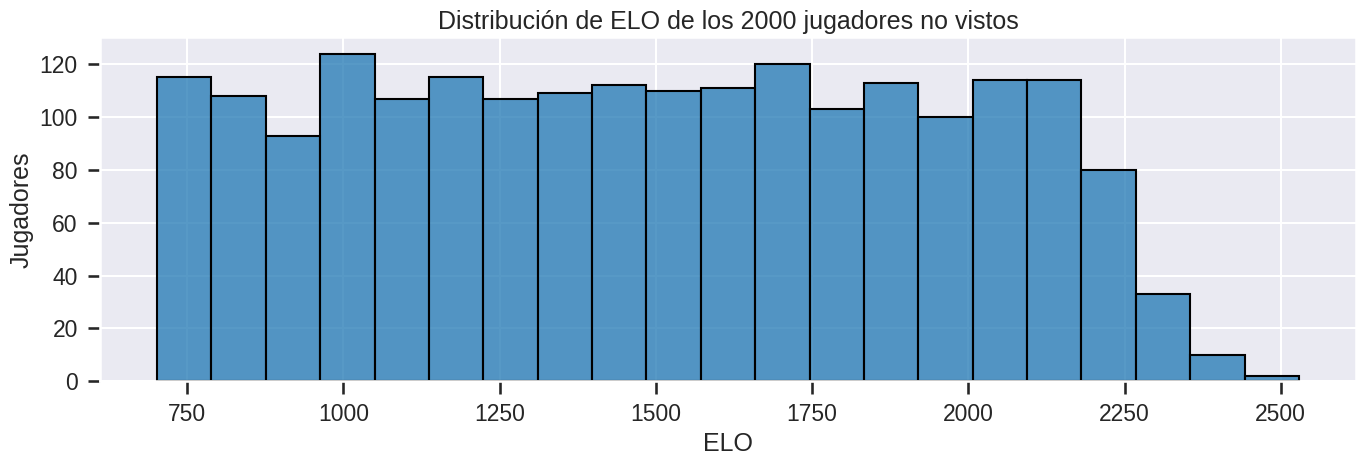

In [12]:
def sample_candidate_players_from_index(
    db_path: Path,
    min_games: int,
    limit: int,
) -> List[Tuple[str, int]]:
    conn = sqlite3.connect(str(db_path))
    try:
        cur = conn.cursor()
        cur.execute(
            "SELECT name, total_games FROM players "
            "WHERE total_games >= ? "
            "ORDER BY RANDOM() LIMIT ?",
            (int(min_games), int(limit)),
        )
        rows = cur.fetchall()
    finally:
        conn.close()
    return [(str(name), int(total_games)) for name, total_games in rows]


def build_candidate_catalog(
    refresh: bool = False,
) -> pd.DataFrame:
    if CATALOG_CSV_PATH.exists() and not refresh:
        catalog_df = pd.read_csv(CATALOG_CSV_PATH)
        if not catalog_df.empty:
            print(f"Usando catálogo existente: {CATALOG_CSV_PATH}")
            return catalog_df

    known_norm = {_norm_player(p) for p in TRAINED_PLAYERS}
    seen_players = set()
    rows = []

    for round_idx in range(CONFIG.catalog_max_rounds):
        candidate_rows = sample_candidate_players_from_index(
            db_path=INDEX_DB,
            min_games=CONFIG.min_games_in_db,
            limit=CONFIG.catalog_query_batch,
        )

        if not candidate_rows:
            break

        print(
            f"Catálogo round {round_idx + 1}/{CONFIG.catalog_max_rounds} | "
            f"candidatos SQL={len(candidate_rows)} | con_elo={len(rows)}"
        )

        for player_name, total_games in candidate_rows:
            player_norm = _norm_player(player_name)
            if player_norm in known_norm or player_norm in seen_players:
                continue

            seen_players.add(player_norm)
            zst_path = find_zst_path(player_name)
            if zst_path is None:
                continue

            elo = extract_elo_from_zst(zst_path)
            if elo is None:
                continue
            if not (CONFIG.elo_min <= elo <= CONFIG.elo_max):
                continue

            rows.append(
                {
                    "player": player_name,
                    "total_games": int(total_games),
                    "elo": int(elo),
                    "zst_path": str(zst_path),
                }
            )

            if len(rows) >= CONFIG.catalog_target_with_elo:
                break

        if len(rows) >= CONFIG.catalog_target_with_elo:
            break

    if not rows:
        raise RuntimeError("No se pudo construir catálogo con ELO válido.")

    catalog_df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["player"])
        .sort_values(["elo", "total_games", "player"])
        .reset_index(drop=True)
    )
    catalog_df.to_csv(CATALOG_CSV_PATH, index=False)
    print(f"Catálogo guardado en {CATALOG_CSV_PATH} con {len(catalog_df)} jugadores.")
    return catalog_df


def stratified_round_robin_sample(
    catalog_df: pd.DataFrame,
    target_players: int,
    bin_size: int,
    seed: int,
) -> pd.DataFrame:
    if len(catalog_df) < target_players:
        raise RuntimeError(
            f"Catálogo insuficiente: {len(catalog_df)} < {target_players}"
        )

    work = catalog_df.copy()
    bins = list(range(CONFIG.elo_min, CONFIG.elo_max + bin_size, bin_size))
    work["elo_bin"] = pd.cut(
        work["elo"],
        bins=bins,
        labels=False,
        include_lowest=True,
    )
    work = work.dropna(subset=["elo_bin"]).copy()
    work["elo_bin"] = work["elo_bin"].astype(int)

    rng = random.Random(seed)
    per_bin_records: Dict[int, List[dict]] = {}
    for elo_bin, group in work.groupby("elo_bin"):
        records = group.to_dict("records")
        rng.shuffle(records)
        per_bin_records[int(elo_bin)] = records

    non_empty_bins = sorted(per_bin_records.keys())
    if not non_empty_bins:
        raise RuntimeError("No hay bins de ELO no vacíos en el catálogo.")

    selected = []
    cursor_by_bin = {elo_bin: 0 for elo_bin in non_empty_bins}

    while len(selected) < target_players:
        progressed = False
        for elo_bin in non_empty_bins:
            cursor = cursor_by_bin[elo_bin]
            items = per_bin_records[elo_bin]
            if cursor >= len(items):
                continue
            selected.append(items[cursor])
            cursor_by_bin[elo_bin] += 1
            progressed = True
            if len(selected) >= target_players:
                break
        if not progressed:
            break

    if len(selected) < target_players:
        raise RuntimeError(
            f"No fue posible seleccionar {target_players} jugadores variados por ELO."
        )

    selected_df = (
        pd.DataFrame(selected)
        .drop(columns=["elo_bin"], errors="ignore")
        .sort_values("elo")
        .reset_index(drop=True)
    )
    return selected_df


catalog_df = build_candidate_catalog(refresh=False)
selected_unknown_players_df = stratified_round_robin_sample(
    catalog_df=catalog_df,
    target_players=CONFIG.target_unknown_players,
    bin_size=CONFIG.elo_bin_size,
    seed=SEED,
)
selected_unknown_players_df.to_csv(SELECTED_PLAYERS_CSV_PATH, index=False)

print(f"Jugadores no vistos seleccionados: {len(selected_unknown_players_df)}")
display(selected_unknown_players_df.head(20))

plt.figure(figsize=(14, 5))
ax = sns.histplot(
    data=selected_unknown_players_df,
    x="elo",
    bins=max(10, (CONFIG.elo_max - CONFIG.elo_min) // CONFIG.elo_bin_size),
    color="tab:blue",
)
ax.set_title("Distribución de ELO de los 2000 jugadores no vistos")
ax.set_xlabel("ELO")
ax.set_ylabel("Jugadores")
plt.tight_layout()
plt.show()


In [11]:
def pairwise_distance_matrix(
    query_embeddings: np.ndarray,
    ref_embeddings: np.ndarray,
) -> np.ndarray:
    query = np.asarray(query_embeddings, dtype=np.float32)
    reference = np.asarray(ref_embeddings, dtype=np.float32)
    sims = np.clip(query @ reference.T, -1.0, 1.0)
    dist_sq = np.maximum(2.0 - 2.0 * sims, 0.0)
    return np.sqrt(dist_sq + 1e-12).astype(np.float32)


def aggregate_player_distances(
    query_to_ref_dists: np.ndarray,
    ref_labels: np.ndarray,
    num_players: int,
    top_k: int,
    strategy: str = "mean",
    temperature: float = 30.0,
) -> np.ndarray:
    strategy = str(strategy).strip().lower()
    if strategy not in {"mean", "softmin"}:
        raise ValueError("strategy debe ser 'mean' o 'softmin'.")

    out = np.full((query_to_ref_dists.shape[0], num_players), np.inf, dtype=np.float32)
    for player_idx in range(num_players):
        class_mask = ref_labels == player_idx
        class_dists = query_to_ref_dists[:, class_mask]
        if class_dists.size == 0:
            continue

        k = min(max(1, int(top_k)), class_dists.shape[1])
        topk = np.partition(class_dists, kth=k - 1, axis=1)[:, :k]
        topk.sort(axis=1)

        if strategy == "mean" or k == 1:
            out[:, player_idx] = topk.mean(axis=1)
            continue

        weights = np.exp(-float(temperature) * topk)
        weights_sum = np.maximum(weights.sum(axis=1, keepdims=True), 1e-8)
        out[:, player_idx] = np.sum(weights * topk, axis=1) / weights_sum[:, 0]

    return out


def weighted_average_from_distances(
    values: np.ndarray,
    dists: np.ndarray,
    k: int,
    eps: float = 1e-6,
) -> float:
    values = np.asarray(values, dtype=np.float32)
    dists = np.asarray(dists, dtype=np.float32)

    valid_mask = np.isfinite(values) & np.isfinite(dists)
    values = values[valid_mask]
    dists = dists[valid_mask]
    if values.size == 0:
        return float("nan")

    k = min(max(1, int(k)), values.size)
    order = np.argsort(dists)[:k]
    picked_values = values[order]
    picked_dists = dists[order]
    weights = 1.0 / np.maximum(picked_dists, eps)
    weights_sum = float(np.sum(weights))
    if weights_sum <= 0:
        return float(np.mean(picked_values))
    return float(np.sum(weights * picked_values) / weights_sum)


def predict_elo_from_embeddings(batch_embeddings: np.ndarray) -> pd.DataFrame:
    query_to_ref_dists = pairwise_distance_matrix(batch_embeddings, train_embeddings)

    nearest_ref_idx = np.argmin(query_to_ref_dists, axis=1)
    exemplar_top1_elo = reference_game_elos[nearest_ref_idx]
    exemplar_top1_dist = query_to_ref_dists[np.arange(len(batch_embeddings)), nearest_ref_idx]

    exemplar_knn_elo = np.array(
        [
            weighted_average_from_distances(
                values=reference_game_elos,
                dists=row_dists,
                k=CONFIG.exemplar_knn_k,
                eps=CONFIG.weight_epsilon,
            )
            for row_dists in query_to_ref_dists
        ],
        dtype=np.float32,
    )

    player_memory_dists = aggregate_player_distances(
        query_to_ref_dists=query_to_ref_dists,
        ref_labels=train_labels,
        num_players=len(reference_players),
        top_k=CONFIG.player_memory_top_k,
        strategy=CONFIG.player_memory_strategy,
        temperature=CONFIG.softmin_temperature,
    )
    player_memory_pred_idx = np.argmin(player_memory_dists, axis=1)
    player_memory_top1_elo = reference_player_elos[player_memory_pred_idx]
    player_memory_top1_dist = player_memory_dists[
        np.arange(len(batch_embeddings)), player_memory_pred_idx
    ]
    player_memory_weighted_elo = np.array(
        [
            weighted_average_from_distances(
                values=reference_player_elos,
                dists=row_dists,
                k=CONFIG.player_regression_k,
                eps=CONFIG.weight_epsilon,
            )
            for row_dists in player_memory_dists
        ],
        dtype=np.float32,
    )

    centroid_dists = pairwise_distance_matrix(batch_embeddings, centroid_matrix)
    centroid_pred_idx = np.argmin(centroid_dists, axis=1)
    centroid_top1_elo = reference_player_elos[centroid_pred_idx]
    centroid_top1_dist = centroid_dists[np.arange(len(batch_embeddings)), centroid_pred_idx]
    centroid_weighted_elo = np.array(
        [
            weighted_average_from_distances(
                values=reference_player_elos,
                dists=row_dists,
                k=CONFIG.centroid_regression_k,
                eps=CONFIG.weight_epsilon,
            )
            for row_dists in centroid_dists
        ],
        dtype=np.float32,
    )

    out = pd.DataFrame(
        {
            "pred_elo_exemplar_top1": exemplar_top1_elo,
            "pred_elo_exemplar_knn": exemplar_knn_elo,
            "pred_elo_player_memory_top1": player_memory_top1_elo,
            "pred_elo_player_memory_weighted": player_memory_weighted_elo,
            "pred_elo_centroid_top1": centroid_top1_elo,
            "pred_elo_centroid_weighted": centroid_weighted_elo,
            "dist_exemplar_top1": exemplar_top1_dist,
            "dist_player_memory_top1": player_memory_top1_dist,
            "dist_centroid_top1": centroid_top1_dist,
            "pred_player_memory_top1": [reference_players[idx] for idx in player_memory_pred_idx],
            "pred_centroid_top1": [reference_players[idx] for idx in centroid_pred_idx],
            "pred_player_exemplar_top1": [TRAIN_SAMPLES[idx].player for idx in nearest_ref_idx],
            "pred_game_exemplar_top1": [TRAIN_SAMPLES[idx].game_id for idx in nearest_ref_idx],
        }
    )
    return out


def infer_unknown_player_games(player_row: pd.Series) -> pd.DataFrame:
    player_name = str(player_row["player"])
    player_elo = float(player_row["elo"])
    zst_path = Path(player_row["zst_path"])
    player_seed = stable_player_seed(player_name, SEED)

    sampled_games, scanned_total, useful_seen = sample_random_games_from_zst(
        zst_path=zst_path,
        player_name=player_name,
        sample_size=CONFIG.unknown_games_per_player,
        seed=player_seed,
        max_games_to_scan=CONFIG.max_games_to_scan_per_player,
    )

    if not sampled_games:
        return pd.DataFrame()

    meta_rows = []
    board_batches = []
    heat_batches = []

    for game_index, game, side in sampled_games:
        try:
            boards, heats = build_single_game_tensor(
                game=game,
                side=side,
                sequence_len=CONFIG.sequence_len,
                fullmove_start=CONFIG.fullmove_start,
                fullmove_end=CONFIG.fullmove_end,
                image_size=CONFIG.image_size,
            )
        except Exception:
            continue

        board_batches.append(boards[0])
        heat_batches.append(heats[0])
        meta_rows.append(
            {
                "unknown_player": player_name,
                "unknown_elo": player_elo,
                "game_index": int(game_index),
                "side": side,
                "scanned_total_games_in_file": int(scanned_total),
                "useful_games_seen_in_file": int(useful_seen),
            }
        )

    if not meta_rows:
        return pd.DataFrame()

    boards_np = np.stack(board_batches).astype(np.float32)
    heats_np = np.stack(heat_batches).astype(np.float32)
    emb = embedding_model.predict(
        {"board_sequence": boards_np, "heat_sequence": heats_np},
        batch_size=min(CONFIG.infer_batch_size, len(meta_rows)),
        verbose=0,
    ).astype(np.float32)

    pred_df = predict_elo_from_embeddings(emb)
    out = pd.concat([pd.DataFrame(meta_rows), pred_df], axis=1)
    return out


def save_run_meta() -> None:
    payload = {
        "config": asdict(CONFIG),
        "event_dir": str(EVENT_DIR),
        "index_db": str(INDEX_DB),
        "players_dir": str(ZST_PLAYERS_DIR),
        "reference_players": reference_players,
        "reference_player_elos": [float(x) for x in reference_player_elos],
        "reference_games": int(len(TRAIN_SAMPLES)),
    }
    RUN_META_PATH.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


def evaluate_unknown_players_at_scale(
    selected_players_df: pd.DataFrame,
    resume_existing: bool = True,
) -> pd.DataFrame:
    save_run_meta()

    completed_players = set()
    if resume_existing and GAME_PREDICTIONS_CSV_PATH.exists():
        existing = pd.read_csv(GAME_PREDICTIONS_CSV_PATH)
        if not existing.empty and "unknown_player" in existing.columns:
            counts = (
                existing.groupby("unknown_player")
                .size()
                .rename("games_evaluated")
                .reset_index()
            )
            completed_players = set(
                counts.loc[
                    counts["games_evaluated"] >= CONFIG.player_level_min_valid_games,
                    "unknown_player",
                ].astype(str)
            )
            keep_mask = existing["unknown_player"].astype(str).isin(completed_players)
            existing = existing.loc[keep_mask].reset_index(drop=True)
            existing.to_csv(GAME_PREDICTIONS_CSV_PATH, index=False)
        print(
            f"Resume activo: {len(completed_players)} jugadores ya estaban evaluados."
        )
    elif GAME_PREDICTIONS_CSV_PATH.exists():
        GAME_PREDICTIONS_CSV_PATH.unlink()

    processed_since_flush = 0
    total_targets = len(selected_players_df)

    for idx, (_, row) in enumerate(selected_players_df.iterrows(), start=1):
        player_name = str(row["player"])
        if player_name in completed_players:
            continue

        print(
            f"[{idx}/{total_targets}] Evaluando {player_name} "
            f"(ELO {int(row['elo'])})"
        )
        player_df = infer_unknown_player_games(row)

        if player_df.empty:
            print("  sin partidas válidas")
        else:
            write_header = not GAME_PREDICTIONS_CSV_PATH.exists()
            player_df.to_csv(
                GAME_PREDICTIONS_CSV_PATH,
                mode="a",
                header=write_header,
                index=False,
            )
            print(f"  partidas válidas guardadas: {len(player_df)}")

        processed_since_flush += 1
        if processed_since_flush >= CONFIG.save_every_players:
            processed_since_flush = 0
            gc.collect()

    if not GAME_PREDICTIONS_CSV_PATH.exists():
        raise RuntimeError("No se generaron predicciones.")

    return pd.read_csv(GAME_PREDICTIONS_CSV_PATH)


game_predictions_df = evaluate_unknown_players_at_scale(
    selected_players_df=selected_unknown_players_df,
    resume_existing=CONFIG.resume_existing,
)

print(f"Predicciones a nivel partida: {len(game_predictions_df)}")
display(game_predictions_df.head(20))


Resume activo: 2000 jugadores ya estaban evaluados.
Predicciones a nivel partida: 40000


,unknown_player,unknown_elo,game_index,side,scanned_total_games_in_file,useful_games_seen_in_file,pred_elo_exemplar_top1,pred_elo_exemplar_knn,pred_elo_player_memory_top1,pred_elo_player_memory_weighted,pred_elo_centroid_top1,pred_elo_centroid_weighted,dist_exemplar_top1,dist_player_memory_top1,dist_centroid_top1,pred_player_memory_top1,pred_centroid_top1,pred_player_exemplar_top1,pred_game_exemplar_top1
0,colintrepide,702.0,10,white,269,269,755.0,998.82214,755.0,1293.9609,755.0,1076.9944,0.035793,0.037177,0.037153,sabino31,sabino31,sabino31,73
1,colintrepide,702.0,41,black,269,269,1889.0,1702.88300,1889.0,1699.8336,1889.0,1748.4465,0.026008,0.029651,0.023680,V2ethereum,V2ethereum,V2ethereum,104
2,colintrepide,702.0,45,white,269,269,1229.0,1294.11870,755.0,1246.2426,941.0,1160.7825,0.033176,0.034901,0.030210,sabino31,ujjawal305,Migrant-is,30
3,colintrepide,702.0,89,black,269,269,1889.0,1503.35410,1889.0,1488.9916,1460.0,1476.9309,0.029254,0.032907,0.030119,V2ethereum,edulol,V2ethereum,149
4,colintrepide,702.0,91,black,269,269,941.0,1100.84790,941.0,1197.0757,941.0,1163.5286,0.023356,0.030888,0.029033,ujjawal305,ujjawal305,ujjawal305,74
5,colintrepide,702.0,112,white,269,269,1197.0,1250.98670,1653.0,1209.7721,941.0,1172.8655,0.031488,0.034998,0.028672,shanis34,ujjawal305,Arsibbalt-1991,116
6,colintrepide,702.0,113,white,269,269,1653.0,1666.07100,1460.0,1690.9077,1889.0,1738.7050,0.028726,0.031344,0.027868,edulol,V2ethereum,shanis34,14
7,colintrepide,702.0,123,black,269,269,755.0,1363.12880,1460.0,1117.8564,755.0,1087.7485,0.033966,0.035382,0.030870,edulol,sabino31,sabino31,12
8,colintrepide,702.0,124,black,269,269,1229.0,1429.31600,1653.0,1381.7938,1229.0,1297.3849,0.029857,0.032245,0.030591,shanis34,Migrant-is,Migrant-is,46
9,colintrepide,702.0,153,black,269,269,1460.0,1384.87880,1460.0,1395.1627,755.0,1110.3698,0.032757,0.034623,0.034464,edulol,sabino31,edulol,76


,method,coverage_games,mae,rmse,median_ae,corr
0,pred_elo_centroid_weighted,40000,348.426868,424.309518,311.98200,0.410252
1,pred_elo_exemplar_knn,40000,351.301247,423.921529,321.07735,0.413810
2,pred_elo_player_memory_weighted,40000,355.955359,427.608788,329.43195,0.400794
3,pred_elo_centroid_top1,40000,399.015450,508.860732,322.00000,0.382646
4,pred_elo_player_memory_top1,40000,420.611500,528.404740,351.00000,0.299705
5,pred_elo_exemplar_top1,40000,442.645525,554.358729,369.00000,0.246984


Resumen por jugador guardado en /workspace/code/labs/notebooks/output/events/benchmark_122_elo_scale_120/player_level_summary.csv


,method,coverage_players,mae,rmse,median_ae,corr
0,pred_elo_centroid_top1,2000,261.029550,312.218274,241.150000,0.803339
1,pred_elo_player_memory_top1,2000,297.495100,350.992881,282.875000,0.734578
2,pred_elo_centroid_weighted,2000,311.914285,364.212401,308.820315,0.811624
3,pred_elo_exemplar_top1,2000,316.649125,372.321083,309.125000,0.700542
4,pred_elo_exemplar_knn,2000,322.758650,376.557762,320.192115,0.795779
5,pred_elo_player_memory_weighted,2000,332.664770,388.211488,329.163252,0.807642


RESUMEN EJECUTIVO · OPEN-SET ELO AT SCALE
Jugadores objetivo: 2000
Partidas por jugador: 20
Partidas válidas evaluadas: 40000
Jugadores con resumen: 2000
Mejor método por partida: pred_elo_centroid_weighted
Mejor método por jugador: pred_elo_centroid_top1


/tmp/ipykernel_11508/2339024480.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_11508/2339024480.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


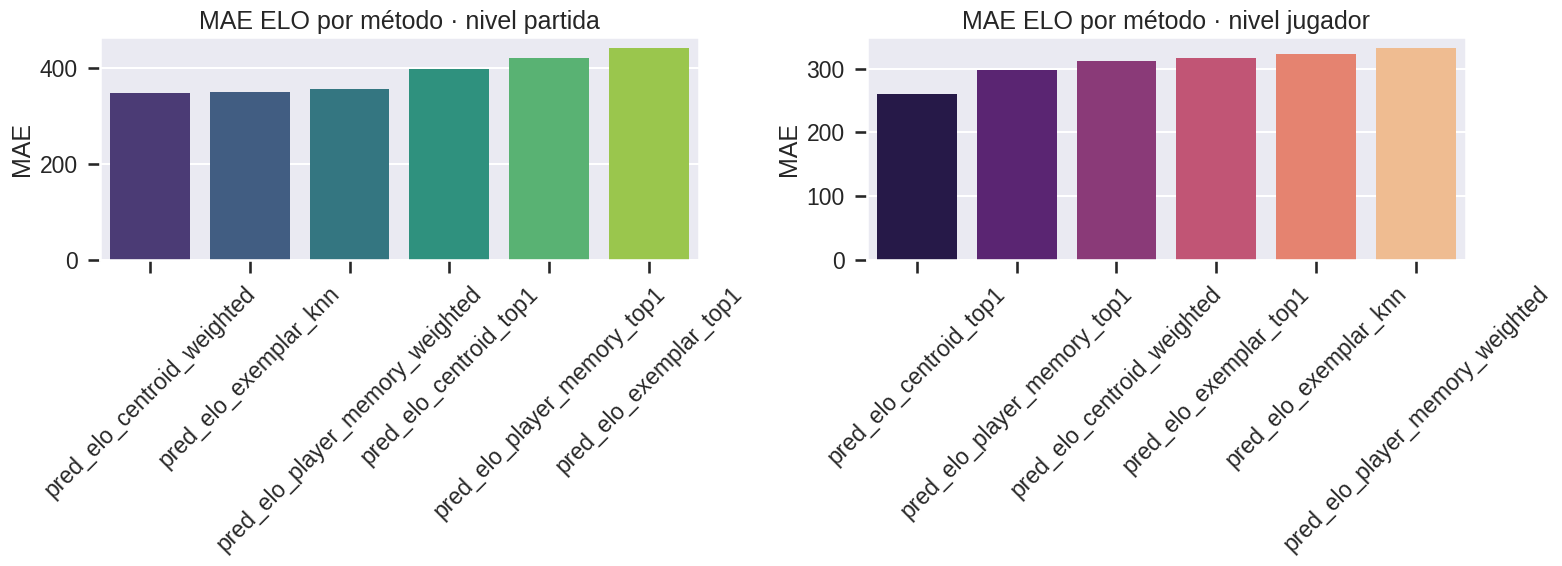

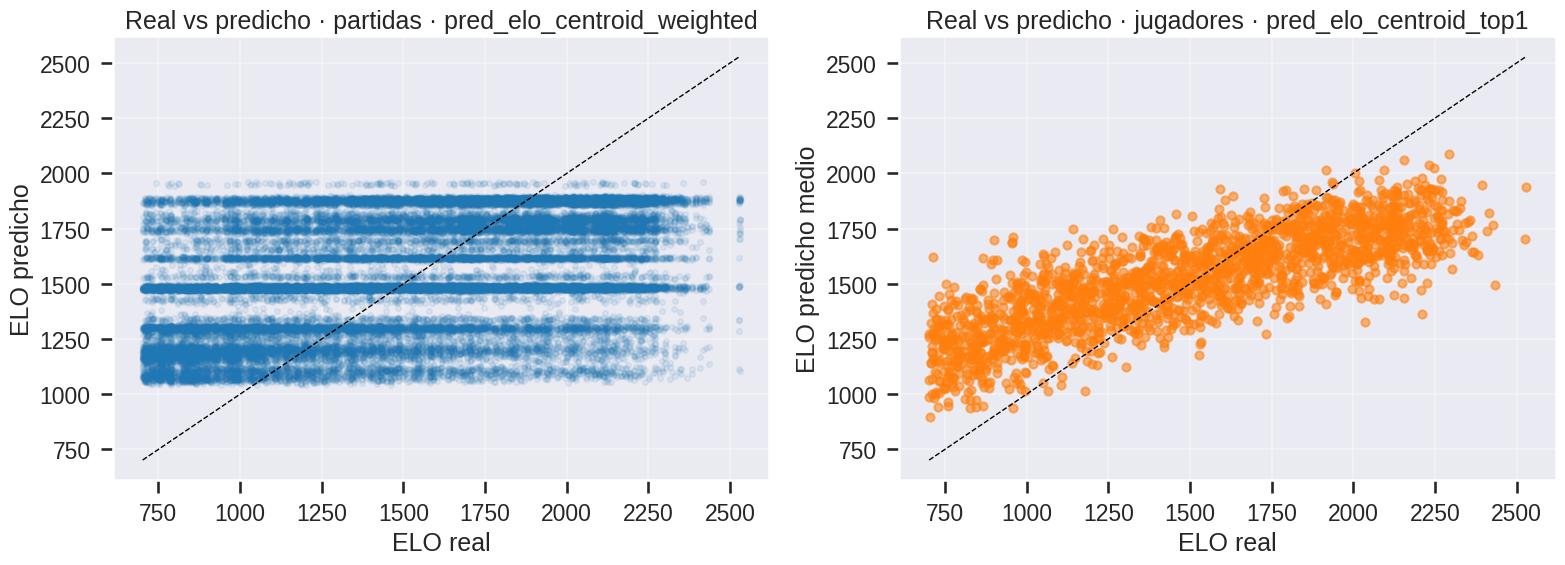

/tmp/ipykernel_11508/2339024480.py:203: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


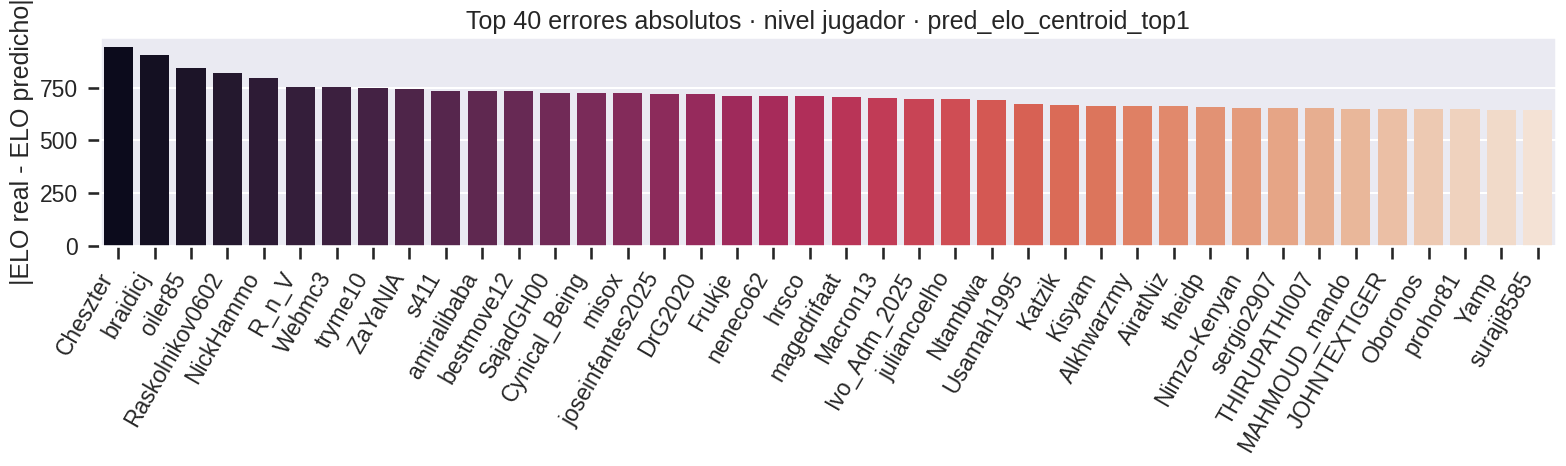

,unknown_player,unknown_elo,games_evaluated,pred_elo_exemplar_top1,pred_elo_exemplar_knn,pred_elo_player_memory_top1,pred_elo_player_memory_weighted,pred_elo_centroid_top1,pred_elo_centroid_weighted,dist_exemplar_top1_mean,dist_player_memory_top1_mean,dist_centroid_top1_mean,abs_error__pred_elo_exemplar_top1,abs_error__pred_elo_exemplar_knn,abs_error__pred_elo_player_memory_top1,abs_error__pred_elo_player_memory_weighted,abs_error__pred_elo_centroid_top1,abs_error__pred_elo_centroid_weighted
0,tycrite67,702.0,20,1523.00,1435.618035,1370.25,1443.162210,1272.65,1368.549165,0.029534,0.033250,0.032621,821.00,733.618035,668.25,741.162210,570.65,666.549165
1,sean4786,702.0,20,1041.00,1204.924160,1063.55,1338.910120,1063.30,1276.254030,0.034660,0.037694,0.039411,339.00,502.924160,361.55,636.910120,361.30,574.254030
2,colintrepide,702.0,20,1351.05,1438.209862,1460.70,1410.256520,1258.50,1365.225330,0.029910,0.032920,0.031229,649.05,736.209862,758.70,708.256520,556.50,663.225330
3,Shonisani,702.0,20,1324.20,1267.335730,1133.30,1341.630950,988.25,1260.317480,0.032205,0.035263,0.035729,622.20,565.335730,431.30,639.630950,286.25,558.317480
4,mancozki,706.0,20,1191.85,1183.594975,1101.65,1289.295735,896.95,1174.098145,0.033197,0.036424,0.037655,485.85,477.594975,395.65,583.295735,190.95,468.098145
5,abangcik0912,709.0,20,1291.55,1321.966136,1229.60,1360.929940,1141.85,1270.514970,0.032478,0.035960,0.035646,582.55,612.966136,520.60,651.929940,432.85,561.514970
6,mohamedhajbakri,709.0,20,1351.45,1351.515870,1211.60,1385.396015,1143.15,1317.358685,0.031264,0.034504,0.033244,642.45,642.515870,502.60,676.396015,434.15,608.358685
7,monsieur_camote,709.0,20,1460.15,1489.609050,1488.80,1516.080900,1323.60,1441.316905,0.031268,0.034289,0.033511,751.15,780.609050,779.80,807.080900,614.60,732.316905
8,juliancoelho,710.0,20,1411.15,1450.802725,1359.55,1490.455640,1406.40,1446.587610,0.030679,0.034068,0.034610,701.15,740.802725,649.55,780.455640,696.40,736.587610
9,rintarolevekarnte,710.0,20,1391.10,1417.496375,1390.45,1446.740705,1219.30,1376.183705,0.029591,0.032994,0.032958,681.10,707.496375,680.45,736.740705,509.30,666.183705


In [10]:
prediction_cols = [
    "pred_elo_exemplar_top1",
    "pred_elo_exemplar_knn",
    "pred_elo_player_memory_top1",
    "pred_elo_player_memory_weighted",
    "pred_elo_centroid_top1",
    "pred_elo_centroid_weighted",
]

eval_df = game_predictions_df.copy()
for col in prediction_cols:
    eval_df[f"abs_error__{col}"] = (eval_df[col] - eval_df["unknown_elo"]).abs()
    eval_df[f"sq_error__{col}"] = (eval_df[col] - eval_df["unknown_elo"]) ** 2


metric_rows = []
for col in prediction_cols:
    valid = eval_df.dropna(subset=[col, "unknown_elo"]).copy()
    if valid.empty:
        continue

    mae = float(np.mean(np.abs(valid[col] - valid["unknown_elo"])))
    rmse = float(np.sqrt(np.mean((valid[col] - valid["unknown_elo"]) ** 2)))
    medae = float(np.median(np.abs(valid[col] - valid["unknown_elo"])))
    corr = (
        float(np.corrcoef(valid["unknown_elo"], valid[col])[0, 1])
        if len(valid) >= 2
        else np.nan
    )
    metric_rows.append(
        {
            "method": col,
            "coverage_games": int(len(valid)),
            "mae": mae,
            "rmse": rmse,
            "median_ae": medae,
            "corr": corr,
        }
    )

game_metrics_df = (
    pd.DataFrame(metric_rows)
    .sort_values(["mae", "rmse", "method"])
    .reset_index(drop=True)
)
display(game_metrics_df)


player_summary_df = (
    eval_df.groupby(["unknown_player", "unknown_elo"], as_index=False)
    .agg(
        games_evaluated=("game_index", "count"),
        pred_elo_exemplar_top1=("pred_elo_exemplar_top1", "mean"),
        pred_elo_exemplar_knn=("pred_elo_exemplar_knn", "mean"),
        pred_elo_player_memory_top1=("pred_elo_player_memory_top1", "mean"),
        pred_elo_player_memory_weighted=("pred_elo_player_memory_weighted", "mean"),
        pred_elo_centroid_top1=("pred_elo_centroid_top1", "mean"),
        pred_elo_centroid_weighted=("pred_elo_centroid_weighted", "mean"),
        dist_exemplar_top1_mean=("dist_exemplar_top1", "mean"),
        dist_player_memory_top1_mean=("dist_player_memory_top1", "mean"),
        dist_centroid_top1_mean=("dist_centroid_top1", "mean"),
    )
    .sort_values("unknown_elo")
    .reset_index(drop=True)
)
player_summary_df = (
    player_summary_df.loc[
        player_summary_df["games_evaluated"] >= CONFIG.player_level_min_valid_games
    ]
    .copy()
    .reset_index(drop=True)
)

for col in prediction_cols:
    player_summary_df[f"abs_error__{col}"] = (
        player_summary_df[col] - player_summary_df["unknown_elo"]
    ).abs()

player_summary_df.to_csv(PLAYER_SUMMARY_CSV_PATH, index=False)
print(f"Resumen por jugador guardado en {PLAYER_SUMMARY_CSV_PATH}")


player_metric_rows = []
for col in prediction_cols:
    valid = player_summary_df.dropna(subset=[col, "unknown_elo"]).copy()
    if valid.empty:
        continue

    mae = float(np.mean(np.abs(valid[col] - valid["unknown_elo"])))
    rmse = float(np.sqrt(np.mean((valid[col] - valid["unknown_elo"]) ** 2)))
    medae = float(np.median(np.abs(valid[col] - valid["unknown_elo"])))
    corr = (
        float(np.corrcoef(valid["unknown_elo"], valid[col])[0, 1])
        if len(valid) >= 2
        else np.nan
    )
    player_metric_rows.append(
        {
            "method": col,
            "coverage_players": int(len(valid)),
            "mae": mae,
            "rmse": rmse,
            "median_ae": medae,
            "corr": corr,
        }
    )

player_metrics_df = (
    pd.DataFrame(player_metric_rows)
    .sort_values(["mae", "rmse", "method"])
    .reset_index(drop=True)
)
display(player_metrics_df)

best_game_method = str(game_metrics_df.iloc[0]["method"])
best_player_method = str(player_metrics_df.iloc[0]["method"])

print("=" * 90)
print("RESUMEN EJECUTIVO · OPEN-SET ELO AT SCALE")
print("=" * 90)
print(f"Jugadores objetivo: {CONFIG.target_unknown_players}")
print(f"Partidas por jugador: {CONFIG.unknown_games_per_player}")
print(f"Partidas válidas evaluadas: {len(eval_df)}")
print(f"Jugadores con resumen: {len(player_summary_df)}")
print(f"Mejor método por partida: {best_game_method}")
print(f"Mejor método por jugador: {best_player_method}")
print("=" * 90)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=game_metrics_df,
    x="method",
    y="mae",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("MAE ELO por método · nivel partida")
axes[0].set_xlabel("")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=player_metrics_df,
    x="method",
    y="mae",
    palette="magma",
    ax=axes[1],
)
axes[1].set_title("MAE ELO por método · nivel jugador")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

game_plot_df = eval_df.dropna(subset=[best_game_method, "unknown_elo"]).copy()
axes[0].scatter(
    game_plot_df["unknown_elo"],
    game_plot_df[best_game_method],
    alpha=0.08,
    s=15,
    color="tab:blue",
)
if not game_plot_df.empty:
    lo = float(min(game_plot_df["unknown_elo"].min(), game_plot_df[best_game_method].min()))
    hi = float(max(game_plot_df["unknown_elo"].max(), game_plot_df[best_game_method].max()))
    axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_title(f"Real vs predicho · partidas · {best_game_method}")
axes[0].set_xlabel("ELO real")
axes[0].set_ylabel("ELO predicho")
axes[0].grid(True, alpha=0.3)

player_plot_df = player_summary_df.dropna(subset=[best_player_method, "unknown_elo"]).copy()
axes[1].scatter(
    player_plot_df["unknown_elo"],
    player_plot_df[best_player_method],
    alpha=0.55,
    s=35,
    color="tab:orange",
)
if not player_plot_df.empty:
    lo = float(min(player_plot_df["unknown_elo"].min(), player_plot_df[best_player_method].min()))
    hi = float(max(player_plot_df["unknown_elo"].max(), player_plot_df[best_player_method].max()))
    axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[1].set_title(f"Real vs predicho · jugadores · {best_player_method}")
axes[1].set_xlabel("ELO real")
axes[1].set_ylabel("ELO predicho medio")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 5))
top_player_errors_df = (
    player_summary_df[["unknown_player", "unknown_elo", f"abs_error__{best_player_method}"]]
    .sort_values(f"abs_error__{best_player_method}", ascending=False)
    .head(40)
)
ax = sns.barplot(
    data=top_player_errors_df,
    x="unknown_player",
    y=f"abs_error__{best_player_method}",
    palette="rocket",
)
ax.set_title(f"Top 40 errores absolutos · nivel jugador · {best_player_method}")
ax.set_xlabel("")
ax.set_ylabel("|ELO real - ELO predicho|")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

display(player_summary_df.head(20))


## Notas de uso

- Si el proceso se interrumpe, vuelve a ejecutar la celda de evaluación con `resume_existing=True`.
- Si el `reservoir sampling` completo tarda demasiado, puedes poner `CONFIG.max_games_to_scan_per_player`
  a un entero para recortar el coste, pero perderás arbitrariedad real sobre todo el archivo.
- El método principal recomendado para juzgar la promesa del embedding es comparar:
  `pred_elo_exemplar_knn` frente a `pred_elo_player_memory_weighted`.


REPLICA 121 · ELO MEDIO PREDICHO (TOP-1) VS ELO REAL (NO-VISTO)
Jugadores no vistos válidos: 2000
Partidas mínimas por jugador exigidas: 5
MAE ELO (top-1 medio por jugador):  297.50
RMSE ELO (top-1 medio por jugador): 350.99
Correlación real/predicho:         0.7346


,unknown_player,unknown_elo,games_evaluated,pred_elo_mean,top1_dist_mean,elo_abs_error
0,tycrite67,702.0,20,1370.25,0.033250,668.25
1,sean4786,702.0,20,1063.55,0.037694,361.55
2,colintrepide,702.0,20,1460.70,0.032920,758.70
3,Shonisani,702.0,20,1133.30,0.035263,431.30
4,mancozki,706.0,20,1101.65,0.036424,395.65
5,abangcik0912,709.0,20,1229.60,0.035960,520.60
6,mohamedhajbakri,709.0,20,1211.60,0.034504,502.60
7,monsieur_camote,709.0,20,1488.80,0.034289,779.80
8,juliancoelho,710.0,20,1359.55,0.034068,649.55
9,rintarolevekarnte,710.0,20,1390.45,0.032994,680.45


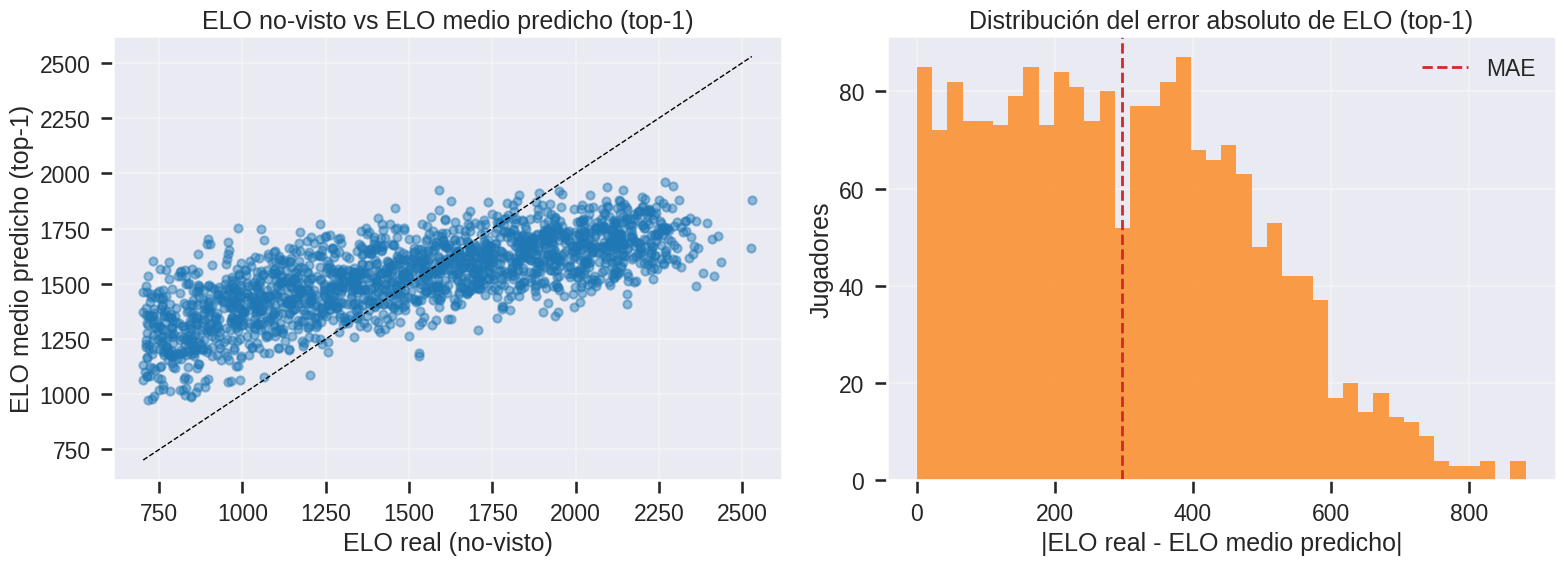

In [9]:
top1_elo_summary_df = (
    eval_df.groupby(["unknown_player", "unknown_elo"], as_index=False)
    .agg(
        games_evaluated=("game_index", "count"),
        pred_elo_mean=("pred_elo_player_memory_top1", "mean"),
        top1_dist_mean=("dist_player_memory_top1", "mean"),
    )
    .sort_values("unknown_elo")
    .reset_index(drop=True)
)
top1_elo_summary_df = (
    top1_elo_summary_df.loc[
        top1_elo_summary_df["games_evaluated"] >= CONFIG.player_level_min_valid_games
    ]
    .copy()
    .reset_index(drop=True)
)
top1_elo_summary_df["elo_abs_error"] = (
    top1_elo_summary_df["pred_elo_mean"] - top1_elo_summary_df["unknown_elo"]
).abs()

top1_valid_df = top1_elo_summary_df.dropna(subset=["pred_elo_mean", "unknown_elo"]).copy()
elo_mae_top1 = float(
    np.mean(np.abs(top1_valid_df["pred_elo_mean"] - top1_valid_df["unknown_elo"]))
)
elo_rmse_top1 = float(
    np.sqrt(np.mean((top1_valid_df["pred_elo_mean"] - top1_valid_df["unknown_elo"]) ** 2))
)
elo_corr_top1 = (
    float(np.corrcoef(top1_valid_df["unknown_elo"], top1_valid_df["pred_elo_mean"])[0, 1])
    if len(top1_valid_df) >= 2
    else np.nan
)

print("=" * 90)
print("REPLICA 121 · ELO MEDIO PREDICHO (TOP-1) VS ELO REAL (NO-VISTO)")
print("=" * 90)
print(f"Jugadores no vistos válidos: {len(top1_valid_df)}")
print(f"Partidas mínimas por jugador exigidas: {CONFIG.player_level_min_valid_games}")
print(f"MAE ELO (top-1 medio por jugador):  {elo_mae_top1:.2f}")
print(f"RMSE ELO (top-1 medio por jugador): {elo_rmse_top1:.2f}")
if not np.isnan(elo_corr_top1):
    print(f"Correlación real/predicho:         {elo_corr_top1:.4f}")
else:
    print("Correlación real/predicho:         no disponible")
print("=" * 90)

display(top1_elo_summary_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    top1_valid_df["unknown_elo"],
    top1_valid_df["pred_elo_mean"],
    alpha=0.45,
    s=35,
    color="tab:blue",
)
if not top1_valid_df.empty:
    lo = float(min(top1_valid_df["unknown_elo"].min(), top1_valid_df["pred_elo_mean"].min()))
    hi = float(max(top1_valid_df["unknown_elo"].max(), top1_valid_df["pred_elo_mean"].max()))
    axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_title("ELO no-visto vs ELO medio predicho (top-1)")
axes[0].set_xlabel("ELO real (no-visto)")
axes[0].set_ylabel("ELO medio predicho (top-1)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(
    top1_valid_df["elo_abs_error"],
    bins=40,
    color="tab:orange",
    alpha=0.75,
)
axes[1].axvline(elo_mae_top1, color="tab:red", linestyle="--", linewidth=2, label="MAE")
axes[1].set_title("Distribución del error absoluto de ELO (top-1)")
axes[1].set_xlabel("|ELO real - ELO medio predicho|")
axes[1].set_ylabel("Jugadores")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
